# 05. IEEE-CIS feature homologation: which competition features can we compute on our charges, and do they carry signal?

The team decided (28-Sep) to bring the fraud risk score from a model trained on the IEEE-CIS Fraud Detection competition, because `is_fraud` in the bank data is random (notebooks 02 to 04). The spec `docs/specs/fraud-risk-model-v1-ieee-cis.md` proposes a feature contract that both sources can fill. This notebook checks that proposal against the data:

1. What the competition holds (rows, groups of columns, coverage).
2. Each contract feature computed with the same definition on the competition rows and on our 4.4 M charges.
3. Per feature: signal in the competition (univariate ROC AUC against `isFraud`), signal in our data (against `is_fraud`, expected 0.50), distribution overlap between the two sources, and the domain gap (how well the feature alone tells the sources apart).
4. A homologation verdict per feature: keep, keep with binning, or drop.

Aggregates only: no competition row and no bank row is printed. Sources: `data/kaggle/train_transaction.csv` and `train_identity.csv` (git-ignored, competition licence), `data/lakehouse_full.duckdb`.

In [1]:
import warnings, time
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#e6e5e1", "font.size": 9})
BLUE, ORANGE, RED, GRAY, GREEN = "#2a78d6", "#eb6834", "#e34948", "#8a8985", "#2e9e6b"
KAGGLE, FULL = Path("data/kaggle"), Path("data/lakehouse_full.duckdb")
con = duckdb.connect()
con.execute(f"ATTACH '{FULL}' AS bank (READ_ONLY)")
q = lambda sql: con.execute(sql).df()
t0 = time.time()
con.execute(f"""create table ieee as
  select t.TransactionID, t.isFraud, t.TransactionDT, t.TransactionAmt, t.ProductCD, t.card1, t.card2, t.card3, t.card4, t.card5, t.card6,
         t.addr1, t.addr2, t.dist1, t.dist2, t.P_emaildomain, t.R_emaildomain,
         t.C1, t.C2, t.C5, t.C13, t.D1, t.D2, t.D3, t.D4, t.D10, t.D15,
         t.M1, t.M2, t.M3, t.M4, t.M5, t.M6, t.M7, t.M8, t.M9,
         i.DeviceType, i.id_30 as os_name, i.id_31 as browser
  from read_csv_auto('{KAGGLE}/train_transaction.csv', sample_size=50000) t
  left join read_csv_auto('{KAGGLE}/train_identity.csv', sample_size=50000) i using (TransactionID)""")
n_ieee = con.execute("select count(*) from ieee").fetchone()[0]
print(f"competition rows: {n_ieee:,} (loaded in {time.time()-t0:.0f}s); bank charges: {con.execute('select count(*) from bank.silver_transactions').fetchone()[0]:,}")

competition rows: 590,540 (loaded in 3s); bank charges: 4,425,008


## 1. What the competition holds

Vesta's transaction table has 394 columns; the identity table adds 41 for 24% of the rows. Columns are anonymized in groups. The table below is the coverage and the target rate per group, the first thing to know before mapping anything.

In [2]:
inv = q("""select
  count(*) rows_, round(100.0*avg(isFraud),2) fraud_pct,
  round(100.0*avg(case when card6 is not null then 1 else 0 end),1) card6_cov,
  round(100.0*avg(case when addr1 is not null then 1 else 0 end),1) addr1_cov,
  round(100.0*avg(case when dist1 is not null then 1 else 0 end),1) dist1_cov,
  round(100.0*avg(case when P_emaildomain is not null then 1 else 0 end),1) p_email_cov,
  round(100.0*avg(case when R_emaildomain is not null then 1 else 0 end),1) r_email_cov,
  round(100.0*avg(case when D1 is not null then 1 else 0 end),1) d1_cov,
  round(100.0*avg(case when M4 is not null then 1 else 0 end),1) m4_cov,
  round(100.0*avg(case when DeviceType is not null then 1 else 0 end),1) identity_cov,
  round(max(TransactionDT)/86400.0,0) span_days
from ieee""")
print(inv.T.rename(columns={0: "value"}).to_string())
print()
print(q("select ProductCD, count(*) n, round(100.0*avg(isFraud),2) fraud_pct from ieee group by 1 order by n desc").to_string(index=False))
print()
print(q("select card6 card_kind, count(*) n, round(100.0*avg(isFraud),2) fraud_pct from ieee group by 1 order by n desc").to_string(index=False))

                 value
rows_         590540.0
fraud_pct          3.5
card6_cov         99.7
addr1_cov         88.9
dist1_cov         40.3
p_email_cov       84.0
r_email_cov       23.2
d1_cov            99.8
m4_cov            52.3
identity_cov      23.8
span_days        183.0

ProductCD      n  fraud_pct
        W 439670       2.04
        C  68519      11.69
        R  37699       3.78
        H  33024       4.77
        S  11628       5.90

      card_kind      n  fraud_pct
          debit 439938       2.43
         credit 148986       6.68
            NaN   1571       2.48
debit or credit     30       0.00
    charge card     15       0.00


Reading: fraud is 3.5% overall but varies by group (product code C is above 10%, credit cards carry more fraud than debit). That variation is exactly what our label lacks, and it is what the transfer brings.

## 2. The same feature contract on both sources

Definitions follow section 4 of the spec. On the competition side the client id (uid) is `card1`, `addr1` and the normalized `D1` (the day the card started), the recipe of the first-place solution; on our side the uid is the native `product_id`. Every aggregate uses only earlier rows of the same uid.

### 2.1 Competition side

In [3]:
t0 = time.time()
ie = q("""select TransactionID, isFraud, TransactionDT, TransactionAmt, card1, card6, addr1, addr2, dist1, P_emaildomain, D1,
                 M1, M2, M3, M4, M5, M6, M7, M8, M9, DeviceType from ieee""")
ie["day"] = ie.TransactionDT // 86400
ie["hour"] = (ie.TransactionDT // 3600) % 24
ie["day_of_week"] = ie.day % 7
ie["uid"] = ie.card1.astype(str) + "_" + ie.addr1.fillna(-1).astype(int).astype(str) + "_" + (ie.day - ie.D1.fillna(-9999)).astype(int).astype(str)
ie["ts"] = pd.to_datetime(ie.TransactionDT, unit="s", origin="2017-12-01")
ie = ie.sort_values(["uid", "ts"]).reset_index(drop=True)
g = ie.groupby("uid", sort=False)
for win, lab in (("1D", "1d"), ("7D", "7d"), ("30D", "30d")):
    r = g.rolling(win, on="ts")["TransactionAmt"].agg(["count", "sum"]).reset_index(level=0, drop=True).sort_index()
    ie[f"tx_count_card_{lab}"] = (r["count"].to_numpy() - 1).clip(min=0)
    if lab == "7d": ie["tx_sum_card_7d"] = r["sum"].to_numpy() - ie.TransactionAmt.to_numpy()
prev = g["TransactionAmt"].shift(1)
ie["amount_mean_card_hist"] = g["TransactionAmt"].transform(lambda s: s.shift(1).expanding().mean())
ie["amount_std_card_hist"] = g["TransactionAmt"].transform(lambda s: s.shift(1).expanding().std())
nprev = g.cumcount()
ie["amount_zscore_card"] = np.where(nprev >= 3, (ie.TransactionAmt - ie.amount_mean_card_hist) / ie.amount_std_card_hist.replace(0, np.nan), 0.0)
ie["ratio_to_historical_avg"] = np.where(nprev >= 1, ie.TransactionAmt / ie.amount_mean_card_hist.replace(0, np.nan), 1.0)
ie["days_since_prev_tx_card"] = (ie.ts - g["ts"].shift(1)).dt.total_seconds() / 86400
ie["cards_per_customer"] = 1.0  # the competition uid is one card; kept for column parity
ie["amount_usd"] = ie.TransactionAmt.clip(lower=0)
ie["log_amount_usd"] = np.log1p(ie.amount_usd)
ie["amount_has_cents"] = ((ie.TransactionAmt * 100).round() % 100 != 0).astype(int)
ie["hour_sin"], ie["hour_cos"] = np.sin(2*np.pi*ie.hour/24), np.cos(2*np.pi*ie.hour/24)
ie["card_kind_credit"] = (ie.card6 == "credit").astype(int)
ie["card_kind_debit"] = (ie.card6 == "debit").astype(int)
ie["card_age_days"] = ie.D1
ie["address_distance_bucket"] = np.select([ie.dist1.isna(), ie.dist1 == 0, ie.dist1 <= 50], [np.nan, 0, 1], 2)
mcols = ["M1","M2","M3","M5","M6","M7","M8","M9"]  # M4 holds the codes M0, M1, M2, not a match flag; DuckDB reads T/F as booleans
mflag = ie[mcols].apply(lambda s: s.map({True: 1, "T": 1, False: 0, "F": 0}))
mt = mflag.sum(axis=1); mn = mflag.notna().sum(axis=1)
ie["consistency_matches"] = np.where(mn > 0, mt / mn, np.nan)
dom_freq = ie.P_emaildomain.value_counts(normalize=True)
ie["email_domain_freq"] = ie.P_emaildomain.map(dom_freq)
ie["card_not_present"] = 1
ie["label"] = ie.isFraud.astype(int)
print(f"competition features built in {time.time()-t0:.0f}s; distinct uids: {ie.uid.nunique():,}; rows with at least one earlier uid row: {(nprev>0).mean()*100:.1f}%")

competition features built in 60s; distinct uids: 218,030; rows with at least one earlier uid row: 63.1%


### 2.2 Bank side

Computed in DuckDB over all 4,425,008 charges (window functions per `product_id`, earlier rows only), then sampled: every flagged charge plus 600,000 unflagged ones, which is enough for AUCs and quantiles and keeps the notebook light.

In [4]:
t0 = time.time()
con.execute("""create table bank_feat as
with base as (
  select t.transaction_id, t.product_id, t.customer_id, t.transaction_date - interval 6 hour as ts, t.process_date,
         coalesce(t.amount_usd, 0) as amount_usd, t.amount, t.channel, t.transaction_type, t.transaction_country, t.transaction_city, t.currency,
         t.is_fraud::int as label,
         p.product_type, p.opening_date, p.currency as product_currency,
         c.country as home_country, c.city as home_city, split_part(c.email, '@', 2) as email_domain
  from bank.silver_transactions t
  left join bank.silver_products p using (product_id)
  left join bank.silver_customers c on c.customer_id = t.customer_id),
w as (
  select *,
    count(*) over (partition by product_id order by ts range between interval 1 day preceding and current row) - 1 as tx_count_card_1d,
    count(*) over (partition by product_id order by ts range between interval 7 day preceding and current row) - 1 as tx_count_card_7d,
    count(*) over (partition by product_id order by ts range between interval 30 day preceding and current row) - 1 as tx_count_card_30d,
    sum(amount_usd) over (partition by product_id order by ts range between interval 7 day preceding and current row) - amount_usd as tx_sum_card_7d,
    count(*) over (partition by customer_id order by ts range between interval 7 day preceding and current row) - 1 as tx_count_customer_7d,
    avg(amount_usd) over (partition by product_id order by ts rows between unbounded preceding and 1 preceding) as amount_mean_card_hist,
    stddev_samp(amount_usd) over (partition by product_id order by ts rows between unbounded preceding and 1 preceding) as amount_std_card_hist,
    count(*) over (partition by product_id order by ts rows between unbounded preceding and 1 preceding) as n_prev,
    avg(amount_usd) over (partition by customer_id order by ts rows between unbounded preceding and 1 preceding) as cust_mean_hist,
    epoch(ts - lag(ts) over (partition by product_id order by ts)) / 86400.0 as days_since_prev_tx_card,
    count(distinct product_id) over (partition by customer_id order by ts rows between unbounded preceding and current row) as cards_per_customer
  from base)
select transaction_id, label, amount_usd, ln(1 + amount_usd) as log_amount_usd,
  case when abs(amount - round(amount)) > 1e-9 then 1 else 0 end as amount_has_cents,
  sin(2*pi()*extract(hour from ts)/24) as hour_sin, cos(2*pi()*extract(hour from ts)/24) as hour_cos,
  (dayofweek(process_date) + 6) % 7 as day_of_week,
  case when product_type = 'Tarjeta Crédito' then 1 else 0 end as card_kind_credit,
  case when product_type = 'Tarjeta Débito' then 1 else 0 end as card_kind_debit,
  greatest(0, datediff('day', opening_date, process_date)) as card_age_days,
  days_since_prev_tx_card, tx_count_card_1d, tx_count_card_7d, tx_count_card_30d, tx_sum_card_7d, tx_count_customer_7d, cards_per_customer,
  amount_mean_card_hist, amount_std_card_hist,
  case when n_prev >= 3 and amount_std_card_hist > 0 then (amount_usd - amount_mean_card_hist) / amount_std_card_hist else 0 end as amount_zscore_card,
  case when cust_mean_hist > 0 then amount_usd / cust_mean_hist else 1 end as ratio_to_historical_avg,
  case when replace(transaction_country, 'Mexico', 'México') <> replace(home_country, 'Mexico', 'México') then 2
       when lower(transaction_city) is distinct from lower(home_city) then 1 else 0 end as address_distance_bucket,
  ((replace(transaction_country, 'Mexico', 'México') = replace(home_country, 'Mexico', 'México'))::int
   + (lower(transaction_city) = lower(home_city))::int + (currency = product_currency)::int
   + (currency = case replace(transaction_country, 'Mexico', 'México') when 'México' then 'MXN' when 'Colombia' then 'COP' when 'Argentina' then 'ARS' else currency end)::int) / 4.0 as consistency_matches,
  email_domain, case when channel in ('Web', 'App') then 1 else 0 end as card_not_present
from w""")
n_bank, n_pos = con.execute("select count(*), sum(label) from bank_feat").fetchone()
bk = q("select * from bank_feat where label = 1 union all select * from (select * from bank_feat where label = 0 using sample reservoir(600000 rows) repeatable (7))")
bk["email_domain_freq"] = bk.email_domain.map(q("select email_domain, count(*)/sum(count(*)) over () f from bank_feat group by 1").set_index("email_domain")["f"])
print(f"bank features over {n_bank:,} charges ({n_pos:,} flagged) in {time.time()-t0:.0f}s; sample for the comparison: {len(bk):,} rows")
neg = con.execute("select round(100.0*avg(case when t.process_date < p.opening_date then 1 else 0 end), 2) from bank.silver_transactions t join bank.silver_products p using (product_id)").fetchone()[0]
print(f"bank data quirk: {neg}% of charges predate the opening date of their product; card_age_days is clipped at 0 and the quirk goes to the data-quality list")

bank features over 4,425,008 charges (4,316 flagged) in 7s; sample for the comparison: 603,704 rows
bank data quirk: 18.71% of charges predate the opening date of their product; card_age_days is clipped at 0 and the quirk goes to the data-quality list


## 3. Per feature: signal on each side, overlap and domain gap

For each contract feature:

- **AUC competition**: univariate ROC AUC of the feature against `isFraud`, taken as max(AUC, 1 - AUC) so direction does not matter. 0.50 means no monotone signal.
- **Binned AUC competition**: the feature cut into 20 quantile bins and scored by the bin's fraud rate. It catches U-shaped signals that the plain AUC misses (amount is the case: fraud is highest at the two ends).
- **AUC bank**: the same against `is_fraud`. Expected 0.50 everywhere (notebooks 02 to 04).
- **Domain AUC**: how well the feature alone separates competition rows from bank rows (200,000 of each). Near 0.50 means the distributions overlap; above 0.80 means the model would see values it never trained on, and the feature needs binning or dropping.
- Quantiles on both sides for the numeric features.

In [5]:
CONTRACT = ["amount_usd", "log_amount_usd", "amount_has_cents", "hour_sin", "hour_cos", "day_of_week", "card_kind_credit", "card_kind_debit",
            "card_age_days", "days_since_prev_tx_card", "tx_count_card_1d", "tx_count_card_7d", "tx_count_card_30d", "tx_sum_card_7d",
            "cards_per_customer", "amount_mean_card_hist", "amount_std_card_hist", "amount_zscore_card", "ratio_to_historical_avg",
            "address_distance_bucket", "consistency_matches", "email_domain_freq", "card_not_present"]
def uni_auc(y, x):
    m = ~np.isnan(x)
    if m.sum() < 100 or len(np.unique(y[m])) < 2 or np.nanstd(x[m]) == 0: return np.nan
    a = roc_auc_score(y[m], x[m]); return max(a, 1 - a)
def binned_auc(y, x, bins=20):
    m = ~np.isnan(x)
    if m.sum() < 100 or len(np.unique(y[m])) < 2: return np.nan
    xb = pd.qcut(pd.Series(x[m]), q=bins, duplicates="drop", labels=False)
    if xb.nunique() < 2: return np.nan
    rate = pd.Series(y[m]).groupby(xb.to_numpy()).mean()
    return roc_auc_score(y[m], xb.map(rate).to_numpy())
rng = np.random.default_rng(7)
ia = ie.sample(200000, random_state=7); ba = bk.sample(200000, random_state=7)
rows = []
for f in CONTRACT:
    xi = pd.to_numeric(ie[f], errors="coerce").to_numpy(float); xb = pd.to_numeric(bk[f], errors="coerce").to_numpy(float)
    xs = np.concatenate([pd.to_numeric(ia[f], errors="coerce").to_numpy(float), pd.to_numeric(ba[f], errors="coerce").to_numpy(float)])
    ys = np.r_[np.ones(len(ia)), np.zeros(len(ba))]
    rows.append({"feature": f, "auc_competition": uni_auc(ie.label.to_numpy(), xi), "auc_binned_competition": binned_auc(ie.label.to_numpy(), xi), "auc_bank": uni_auc(bk.label.to_numpy(), xb),
                 "domain_auc": uni_auc(ys, np.nan_to_num(xs, nan=-1)), "null_pct_competition": np.isnan(xi).mean()*100, "null_pct_bank": np.isnan(xb).mean()*100,
                 "p50_competition": np.nanmedian(xi), "p50_bank": np.nanmedian(xb), "p95_competition": np.nanpercentile(xi, 95), "p95_bank": np.nanpercentile(xb, 95)})
hom = pd.DataFrame(rows)
def verdict(r):
    if r.feature == "card_not_present": return "drop (constant on the competition side)"
    if r.feature == "cards_per_customer": return "bank-only (one card per competition uid): out of the transfer model"
    if r.feature == "email_domain_freq": return "drop (constant on the bank side: seven uniform domains; fingerprints the source)"
    sig = np.nanmax([r.auc_competition, r.auc_binned_competition, 0.5])
    if sig < 0.55: return "weak signal: keep only if the ablation says so"
    if r.domain_auc >= 0.85: return "signal but shifted: bin or rank before serving"
    return "keep"
hom["verdict"] = hom.apply(verdict, axis=1)
pd.set_option("display.width", 220)
print(hom.round(3).to_string(index=False))

                feature  auc_competition  auc_binned_competition  auc_bank  domain_auc  null_pct_competition  null_pct_bank  p50_competition  p50_bank  p95_competition  p95_bank                                                                          verdict
             amount_usd            0.502                   0.609     0.507       0.887                 0.000          0.000           68.769   467.240          445.000  7556.045                                   signal but shifted: bin or rank before serving
         log_amount_usd            0.502                   0.609     0.507       0.887                 0.000          0.000            4.245     6.149            6.100     8.930                                   signal but shifted: bin or rank before serving
       amount_has_cents            0.507                     NaN     0.501       0.754                 0.000          0.000            0.000     1.000            1.000     1.000                                   weak signal

### 3.1 Signal per feature, competition versus bank

The chart makes the point in one look: on the competition side the contract features separate fraud from non-fraud (best of plain and binned AUC above 0.50, some well above), on the bank side every one sits at 0.50. The transfer is the only way to give the policy a learned score on these definitions.

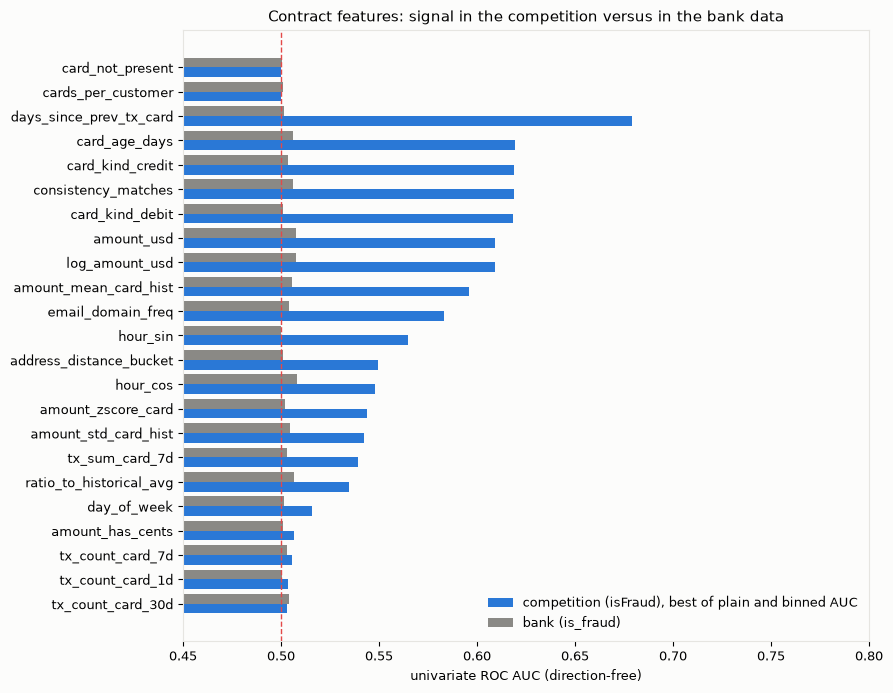

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
h = hom.assign(best=hom[["auc_competition", "auc_binned_competition"]].max(axis=1)).sort_values("best")
y = np.arange(len(h))
ax.barh(y - 0.2, h[["auc_competition", "auc_binned_competition"]].max(axis=1).fillna(0.5), height=0.4, color=BLUE, label="competition (isFraud), best of plain and binned AUC")
ax.barh(y + 0.2, h.auc_bank.fillna(0.5), height=0.4, color=GRAY, label="bank (is_fraud)")
ax.axvline(0.5, color=RED, lw=1, ls="--"); ax.set_xlim(0.45, max(0.8, h.best.max() + 0.03))
ax.set_yticks(y); ax.set_yticklabels(h.feature); ax.set_xlabel("univariate ROC AUC (direction-free)"); ax.set_title("Contract features: signal in the competition versus in the bank data")
ax.legend(frameon=False, loc="lower right"); plt.tight_layout(); plt.savefig("notebooks/18_ieee_feature_signal.png", dpi=130, bbox_inches="tight"); plt.show()

### 3.2 How the fraud rate moves along each feature in the competition

Bucketed fraud rates for the six features that matter most to the policy. The bank rate (0.10%, flat) is drawn as the dashed line for scale: the competition's rate moves by a factor of 3 to 10 across buckets, the bank's does not move at all.

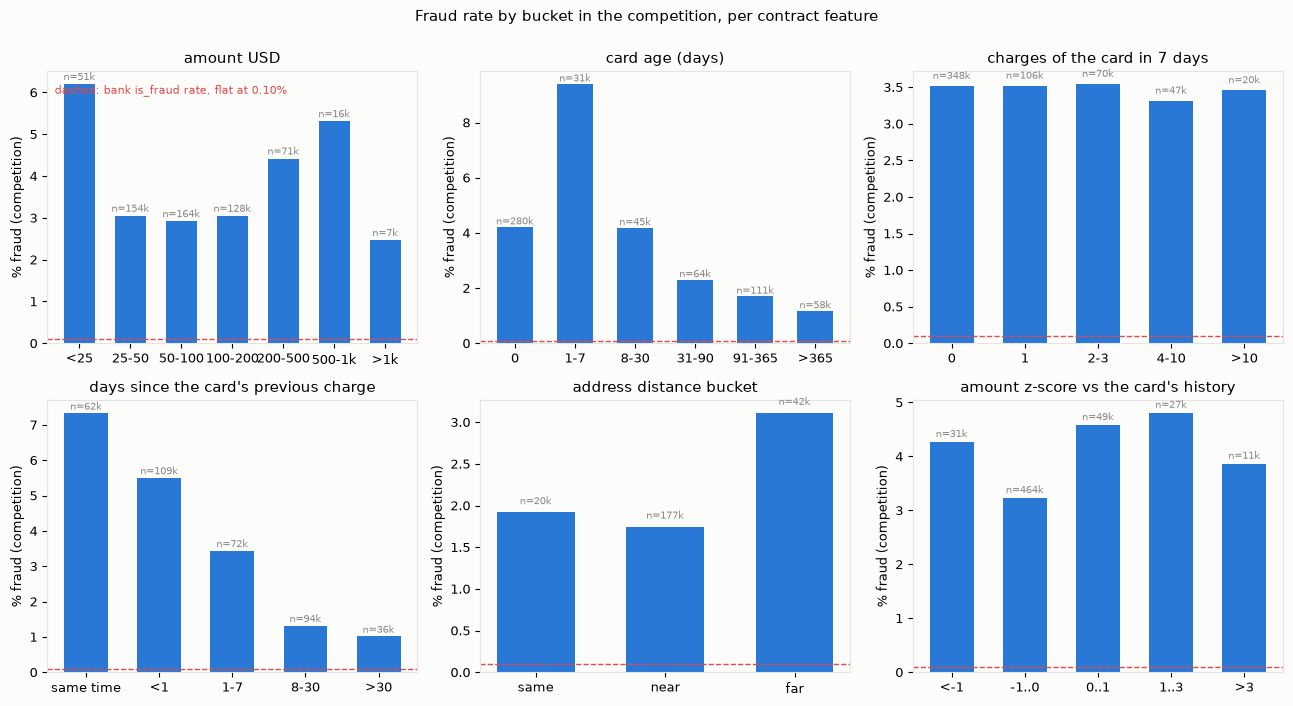

In [7]:
def rate_by_bucket(df, col, bins, labels):
    b = pd.cut(pd.to_numeric(df[col], errors="coerce"), bins=bins, labels=labels, include_lowest=True)
    return df.groupby(b, observed=True)["label"].agg(["mean", "size"])
panels = [("amount_usd", [0, 25, 50, 100, 200, 500, 1000, 1e9], ["<25", "25-50", "50-100", "100-200", "200-500", "500-1k", ">1k"], "amount USD"),
          ("card_age_days", [-1, 0, 7, 30, 90, 365, 1e9], ["0", "1-7", "8-30", "31-90", "91-365", ">365"], "card age (days)"),
          ("tx_count_card_7d", [-1, 0, 1, 3, 10, 1e9], ["0", "1", "2-3", "4-10", ">10"], "charges of the card in 7 days"),
          ("days_since_prev_tx_card", [-1, 0.01, 1, 7, 30, 1e9], ["same time", "<1", "1-7", "8-30", ">30"], "days since the card's previous charge"),
          ("address_distance_bucket", [-1, 0, 1, 2], ["same", "near", "far"], "address distance bucket"),
          ("amount_zscore_card", [-1e9, -1, 0, 1, 3, 1e9], ["<-1", "-1..0", "0..1", "1..3", ">3"], "amount z-score vs the card's history")]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (col, bins, labels, title) in zip(axes.ravel(), panels):
    ri = rate_by_bucket(ie, col, bins, labels); rb = rate_by_bucket(bk, col, bins, labels)
    x = np.arange(len(ri)); ax.bar(x, ri["mean"] * 100, color=BLUE, width=0.6)
    ax.axhline(bk.label.mean() * 100 / (bk.label.mean() / (n_pos / n_bank)), color=RED, ls="--", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(ri.index, rotation=0); ax.set_title(title); ax.set_ylabel("% fraud (competition)")
    for xi_, (m, n) in zip(x, ri.itertuples(index=False)): ax.text(xi_, m * 100 + 0.1, f"n={n/1000:.0f}k", ha="center", fontsize=7, color=GRAY)
axes[0, 0].text(0.02, 0.95, "dashed: bank is_fraud rate, flat at 0.10%", transform=axes[0, 0].transAxes, fontsize=8, color=RED, va="top")
plt.suptitle("Fraud rate by bucket in the competition, per contract feature", y=1.0); plt.tight_layout(); plt.savefig("notebooks/19_ieee_fraud_rate_by_bucket.png", dpi=130, bbox_inches="tight"); plt.show()

### 3.3 Domain gap: do the two sources look alike on these features?

Two views. First the per-feature domain AUC from the table above. Second an adversarial classifier on the contract features at once (200,000 rows per source, gradient boosting): its holdout AUC is the honest measure of how different the bank charges are from the competition rows after the mapping, and the AUC lost when each feature is shuffled names the features that drive the difference. Three fits: raw values with every feature, raw values without the email domain frequency (which fingerprints the source rather than behavior: the bank's seven domains are uniform, so the feature is constant there and useless in serving anyway), and per-source percentile ranks with nulls filled by the source median. The third is the spec's "bin or rank before serving" recipe put to the test. A fourth fit keeps only the continuous features as ranks: ranking equalizes every marginal distribution, so whatever separation remains comes from the joint structure (how the features move together), which no per-feature transform can remove.

adversarial AUC, every contract feature, raw values: 1.000 (email_domain_freq alone fingerprints the source)
adversarial AUC, without email_domain_freq, raw values: 1.000 (null patterns and discrete values still fingerprint)
adversarial AUC, without email_domain_freq, per-source percentile ranks: 1.000 (what the model would see after the rank recipe)


adversarial AUC, continuous features only (14), per-source percentile ranks: 1.000 (ranks equalize each marginal, so this is the joint structure)


                feature  auc_drop_when_shuffled
address_distance_bucket                  0.3501
       card_kind_credit                  0.0031
        card_kind_debit                  0.0002
             amount_usd                  0.0000
       tx_count_card_7d                  0.0000
ratio_to_historical_avg                  0.0000
     amount_zscore_card                  0.0000
   amount_std_card_hist                  0.0000
  amount_mean_card_hist                  0.0000
         tx_sum_card_7d                  0.0000
      tx_count_card_30d                  0.0000
       tx_count_card_1d                  0.0000
         log_amount_usd                  0.0000
days_since_prev_tx_card                  0.0000
          card_age_days                  0.0000
            day_of_week                  0.0000
               hour_cos                  0.0000
               hour_sin                  0.0000
       amount_has_cents                  0.0000
    consistency_matches                 

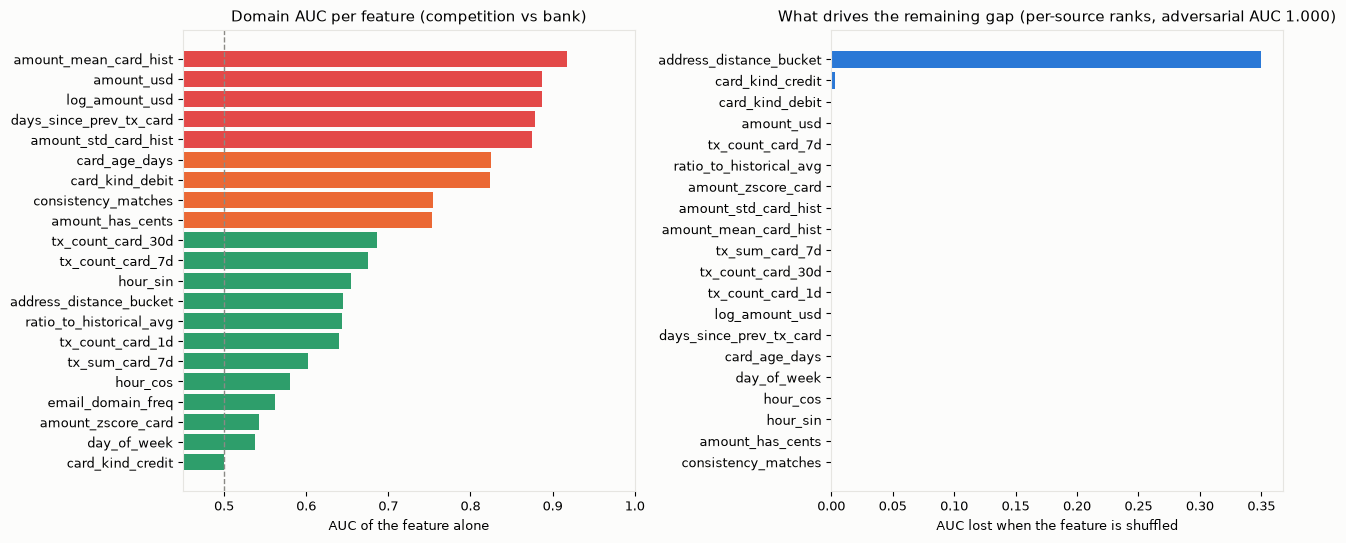

In [8]:
def adversarial(fa, fb):
    Xs = pd.concat([fa, fb]).to_numpy(float)
    ys = np.r_[np.ones(len(fa)), np.zeros(len(fb))]
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.3, random_state=7, stratify=ys)
    m = HistGradientBoostingClassifier(max_iter=150, learning_rate=0.1, random_state=7).fit(Xtr, ytr)
    return m, Xte, yte, roc_auc_score(yte, m.predict_proba(Xte)[:, 1])
num = lambda df, fs: df[fs].apply(pd.to_numeric, errors="coerce")
all_feats = [f for f in CONTRACT if f not in ("card_not_present", "cards_per_customer")]
_, _, _, adv_all = adversarial(num(ia, all_feats), num(ba, all_feats))
# email_domain_freq is a source fingerprint (seven uniform bank domains at 0.14 each, a wide spread on the competition side): it identifies the source without saying anything about behavior.
feats = [f for f in all_feats if f != "email_domain_freq"]
_, _, _, adv_raw = adversarial(num(ia, feats), num(ba, feats))
# Per-source rank transform: each feature becomes its percentile within its own source, nulls filled with the source median first so null patterns stop fingerprinting. This is the "bin or rank before serving" recipe of the spec, tested.
def rank_within(df, fs):
    x = num(df, fs); return x.fillna(x.median()).rank(pct=True)
adv, Xte, yte, adv_auc = adversarial(rank_within(ia, feats), rank_within(ba, feats))
print(f"adversarial AUC, every contract feature, raw values: {adv_all:.3f} (email_domain_freq alone fingerprints the source)")
print(f"adversarial AUC, without email_domain_freq, raw values: {adv_raw:.3f} (null patterns and discrete values still fingerprint)")
print(f"adversarial AUC, without email_domain_freq, per-source percentile ranks: {adv_auc:.3f} (what the model would see after the rank recipe)")
DISCRETE = ["address_distance_bucket", "card_kind_credit", "card_kind_debit", "amount_has_cents", "day_of_week", "consistency_matches"]
cont = [f for f in feats if f not in DISCRETE]
_, _, _, adv_cont = adversarial(rank_within(ia, cont), rank_within(ba, cont))
print(f"adversarial AUC, continuous features only ({len(cont)}), per-source percentile ranks: {adv_cont:.3f} (ranks equalize each marginal, so this is the joint structure)")
drop = []
for j, f in enumerate(feats):
    Xd = Xte.copy(); Xd[:, j] = np.random.default_rng(j).permutation(Xd[:, j])
    drop.append((f, adv_auc - roc_auc_score(yte, adv.predict_proba(Xd)[:, 1])))
imp = pd.DataFrame(drop, columns=["feature", "auc_drop_when_shuffled"]).sort_values("auc_drop_when_shuffled", ascending=False)
print(imp.round(4).to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
ax = axes[0]; h = hom[~hom.feature.isin(["card_not_present", "cards_per_customer"])].sort_values("domain_auc")
ax.barh(h.feature, h.domain_auc, color=[RED if v >= 0.85 else ORANGE if v >= 0.7 else GREEN for v in h.domain_auc])
ax.axvline(0.5, color=GRAY, lw=1, ls="--"); ax.set_xlim(0.45, 1.0); ax.set_title("Domain AUC per feature (competition vs bank)"); ax.set_xlabel("AUC of the feature alone")
ax = axes[1]; ax.barh(imp.feature[::-1], imp.auc_drop_when_shuffled[::-1], color=BLUE)
ax.set_title(f"What drives the remaining gap (per-source ranks, adversarial AUC {adv_auc:.3f})"); ax.set_xlabel("AUC lost when the feature is shuffled")
plt.tight_layout(); plt.savefig("notebooks/20_ieee_vs_bank_domain_gap.png", dpi=130, bbox_inches="tight"); plt.show()

### 3.4 Quantiles side by side

Where the domain AUC is high the quantiles say why: the two sources price and pace transactions differently (the competition is e-commerce in USD with many small amounts and repeat buyers; the bank sample has 1.1 charges per product in June and about 3 per product over three years).

In [9]:
qcols = ["amount_usd", "card_age_days", "days_since_prev_tx_card", "tx_count_card_7d", "tx_count_card_30d", "amount_mean_card_hist", "ratio_to_historical_avg", "consistency_matches", "email_domain_freq"]
qs = [5, 25, 50, 75, 95]
out = []
for f in qcols:
    xi = pd.to_numeric(ie[f], errors="coerce"); xb = pd.to_numeric(bk[f], errors="coerce")
    out.append({"feature": f, **{f"comp_p{p}": np.nanpercentile(xi, p) for p in qs}, **{f"bank_p{p}": np.nanpercentile(xb, p) for p in qs}})
print(pd.DataFrame(out).round(2).to_string(index=False))

                feature  comp_p5  comp_p25  comp_p50  comp_p75  comp_p95  bank_p5  bank_p25  bank_p50  bank_p75  bank_p95
             amount_usd    20.00     43.32     68.77    125.00    445.00    62.14    242.71    467.24   1979.92   7556.05
          card_age_days     0.00      0.00      3.00    122.00    489.00     0.00    185.00    912.00   1644.00   2359.00
days_since_prev_tx_card     0.00      0.04      1.92     12.90     43.89     4.00     22.31     53.95    107.79    231.55
       tx_count_card_7d     0.00      0.00      0.00      1.00      8.00     0.00      0.00      0.00      0.00      1.00
      tx_count_card_30d     0.00      0.00      1.00      3.00     12.00     0.00      0.00      0.00      1.00      1.00
  amount_mean_card_hist    25.10     49.00     78.97    131.61    358.75   202.57    388.60   1320.90   2627.58   4283.63
ratio_to_historical_avg     0.33      0.84      1.00      1.00      2.23     0.04      0.17      0.50      1.41      4.88
    consistency_matches 

## 4. Homologation verdict

The table of section 3 and the three charts give one verdict per contract feature. Written for the spec (section 4 of `docs/specs/fraud-risk-model-v1-ieee-cis.md`) and for the mentors (TQ-026):

In [10]:
v = hom[["feature", "auc_competition", "auc_binned_competition", "auc_bank", "domain_auc", "verdict"]].copy().round(3)
print(v.to_string(index=False))
keep = v[v.verdict == "keep"].feature.tolist(); binned = v[v.verdict.str.startswith("signal but shifted")].feature.tolist()
weak = v[v.verdict.str.startswith("weak")].feature.tolist(); dropped = v[v.verdict.str.startswith("drop")].feature.tolist(); bank_only = v[v.verdict.str.startswith("bank-only")].feature.tolist()
print(f"\nkeep as is ({len(keep)}): {keep}\nkeep after binning or ranking ({len(binned)}): {binned}\nweak, decided by the ablation ({len(weak)}): {weak}\nbank-only ({len(bank_only)}): {bank_only}\ndrop ({len(dropped)}): {dropped}")

                feature  auc_competition  auc_binned_competition  auc_bank  domain_auc                                                                          verdict
             amount_usd            0.502                   0.609     0.507       0.887                                   signal but shifted: bin or rank before serving
         log_amount_usd            0.502                   0.609     0.507       0.887                                   signal but shifted: bin or rank before serving
       amount_has_cents            0.507                     NaN     0.501       0.754                                   weak signal: keep only if the ablation says so
               hour_sin            0.536                   0.565     0.500       0.655                                                                             keep
               hour_cos            0.510                   0.548     0.508       0.581                                   weak signal: keep only if the ablation 

## 5. Level homologation with Jev

The contract covers the numeric features. The categorical variables need a level-by-level homologation: which bank level corresponds to each competition level, and which competition levels have no counterpart. Instead of deciding by hand, each competition level is put to Jev (TypeSafe AI, the same System 1 engine the intake uses, `src/understand/jev_extractor.py`) as a typed `Choice` among the bank's levels plus `no_equivalent`, with the level's official meaning, its share of rows and its fraud rate as the state. Jev returns the full probability distribution, so an ambiguous level shows as split mass rather than a forced answer. The reverse direction (is a bank channel or transaction type of the kind the competition holds?) is a `Noul`, a calibrated yes or no.

Only variable names, level names and aggregate shares travel to Jev: no row of either dataset. Answers are cached in `notebooks/05_jev_level_homologation.json` so the notebook reruns without the key.

In [11]:
import os, json, re
from src.understand.jev_extractor import JevExtractor, JEV_MODEL
if not os.getenv("TYPESAFE_API_KEY") and Path(".env").exists():
    for line in Path(".env").read_text().splitlines():
        if line.startswith("TYPESAFE_API_KEY="): os.environ["TYPESAFE_API_KEY"] = line.split("=", 1)[1].strip().strip('"')
ext = JevExtractor()
CACHE = Path("notebooks/05_jev_level_homologation.json")
cache = json.loads(CACHE.read_text()) if CACHE.exists() else {"model": JEV_MODEL, "choices": {}, "coverage": {}}
print("Jev available:", ext.available(), "| cached answers:", len(cache["choices"]) + len(cache["coverage"]))

def levels(sql):
    d = q(sql); return {str(r[0]): {"share_pct": round(float(r[1]), 2), "fraud_pct": round(float(r[2]), 2)} for r in d.itertuples(index=False)}
def fam_os(v):
    v = str(v).lower()
    return "Windows" if v.startswith("windows") else "iOS" if v.startswith("ios") else "Android" if v.startswith("android") else "Mac OS X" if v.startswith("mac") else "Linux" if v.startswith("linux") else "other"
def fam_browser(v):
    v = str(v).lower()
    for k, lab in (("samsung", "samsung browser"), ("chrome", "chrome"), ("safari", "safari"), ("firefox", "firefox"), ("edge", "edge"), ("ie ", "internet explorer"), ("opera", "opera")):
        if k in v: return lab
    return "other"
con.create_function("fam_os", fam_os, ["VARCHAR"], "VARCHAR"); con.create_function("fam_browser", fam_browser, ["VARCHAR"], "VARCHAR")
TX_TYPES = {"Purchase": "A card purchase at a merchant (POS or online).", "Withdrawal": "A cash withdrawal at an ATM or branch.", "Transfer": "A transfer of money between accounts.",
            "Payment": "A bill, loan or service payment.", "Deposit": "A cash or check deposit into an account.", "Adjustment": "A correction posted by the bank.",
            "no_equivalent": "No bank transaction type corresponds to this level."}
PRODUCTS = {"Tarjeta Crédito": "Credit card.", "Tarjeta Débito": "Debit card.", "Cuenta Ahorro": "Savings account.", "Cuenta Corriente": "Checking account.",
            "Préstamo Personal": "Personal loan.", "Préstamo Hipotecario": "Mortgage loan.", "Inversión": "Investment product.", "Seguro": "Insurance product.",
            "no_equivalent": "No bank product type corresponds to this level."}
EV_CHANNELS = {"Android App": "The bank's Android app.", "iOS App": "The bank's iOS app.", "Desktop Web": "The bank's website on a desktop browser.", "Mobile Web": "The bank's website on a mobile browser.", "no_equivalent": "No bank channel corresponds."}
PLATFORMS = {"Android": "Android.", "iOS": "iOS.", "Linux": "Linux.", "MacOS": "macOS.", "Windows": "Windows.", "no_equivalent": "No bank platform corresponds."}
BROWSERS = {"Chrome": "Google Chrome.", "Safari": "Apple Safari, desktop or mobile.", "Samsung Internet": "Samsung Internet browser.", "Firefox": "Mozilla Firefox.", "Edge": "Microsoft Edge.", "no_equivalent": "No bank browser level corresponds (for example Internet Explorer or Opera)."}
EMAILS = {d: f"The email domain {d}." for d in ["gmail.com", "hotmail.com", "yahoo.com", "outlook.com", "live.com", "icloud.com", "protonmail.com"]}
EMAILS["no_equivalent"] = "No bank email domain corresponds (a different provider, an ISP or a malformed value)."
PAIRS = [
  ("ProductCD", "Product code of the purchased item; Vesta never disclosed what W, H, C, S and R stand for.", levels("select ProductCD, 100.0*count(*)/sum(count(*)) over (), 100.0*avg(isFraud) from ieee group by 1"), "transaction_type", TX_TYPES),
  ("card6", "Card category of the payment card.", levels("select card6, 100.0*count(*)/sum(count(*)) over (), 100.0*avg(isFraud) from ieee where card6 is not null group by 1"), "product_type", PRODUCTS),
  ("card4", "Card network of the payment card.", levels("select card4, 100.0*count(*)/sum(count(*)) over (), 100.0*avg(isFraud) from ieee where card4 is not null group by 1"), "product_type", PRODUCTS),
  ("DeviceType", "Device type of the purchaser's session, from the identity table.", levels("select DeviceType, 100.0*count(*)/sum(count(*)) over (), 100.0*avg(isFraud) from ieee where DeviceType is not null group by 1"), "digital_events.channel", EV_CHANNELS),
  ("id_30 (OS family)", "Operating system of the purchaser's device, collapsed to its family.", levels("select fam_os(os_name), 100.0*count(*)/sum(count(*)) over (), 100.0*avg(isFraud) from ieee where os_name is not null group by 1"), "digital_events.platform", PLATFORMS),
  ("id_31 (browser family)", "Browser of the purchaser's session, collapsed to its family.", levels("select fam_browser(browser), 100.0*count(*)/sum(count(*)) over (), 100.0*avg(isFraud) from ieee where browser is not null group by 1"), "digital_events.browser", BROWSERS),
  ("P_emaildomain", "Email domain of the purchaser.", levels("select P_emaildomain, 100.0*count(*)/sum(count(*)) over (), 100.0*avg(isFraud) from ieee where P_emaildomain is not null group by 1 order by 2 desc limit 20"), "customers.email domain", EMAILS),
]
print("competition levels to homologate:", sum(len(p[2]) for p in PAIRS))

Jev available: True | cached answers: 61


competition levels to homologate: 49


In [12]:
import typesafe_sdk as ts
def ask_choice(var, meaning, level, stats, bank_var, criteria):
    key = f"{var}||{level}"
    if key in cache["choices"]: return cache["choices"][key]
    state = {"competition_variable": var, "official_meaning": meaning, "level": level, "share_of_rows_pct": stats["share_pct"], "fraud_rate_pct": stats["fraud_pct"],
             "bank_variable": bank_var}
    qn = ts.Choice(instructions=f"Which level of the bank variable {bank_var} is the equivalent of this level of the competition variable {var}? Choose no_equivalent when none corresponds.", criteria=criteria)
    r = ext._get_client().system_one(state=state, questions={"bank_level": qn}, model=JEV_MODEL)
    c = r.choices["bank_level"]; usage = getattr(r, "usage", None)
    out = {"choice": str(c.choice), "confidence": float(c.confidence), "probabilities": {str(k): round(float(v), 4) for k, v in (c.probabilities or {}).items()},
           "request_id": getattr(r, "request_id", None), "tokens_in": int(getattr(usage, "input_tokens", 0) or 0)}
    cache["choices"][key] = out; return out
rows = []
if ext.available() or cache["choices"]:
    for var, meaning, lv, bank_var, criteria in PAIRS:
        for level, stats in lv.items():
            try: a = ask_choice(var, meaning, level, stats, bank_var, criteria)
            except Exception as e:
                print("Jev call failed:", type(e).__name__); a = None
            if a is None: continue
            probs = sorted(a["probabilities"].items(), key=lambda kv: -kv[1])
            second = f"{probs[1][0]} ({probs[1][1]:.2f})" if len(probs) > 1 else ""
            verdict = ("no equivalent" if a["choice"] == "no_equivalent" and a["confidence"] >= 0.5 else "homologated" if a["confidence"] >= 0.70 else "ambiguous: human decides")
            rows.append({"competition_var": var, "level": level, "share_pct": stats["share_pct"], "fraud_pct": stats["fraud_pct"], "bank_var": bank_var, "jev_choice": a["choice"],
                         "confidence": round(a["confidence"], 3), "second": second, "verdict": verdict})
    CACHE.write_text(json.dumps(cache, ensure_ascii=False, indent=1))
jev_tab = pd.DataFrame(rows)
tok = sum(v.get("tokens_in", 0) for v in cache["choices"].values())
print(f"answers: {len(jev_tab)} | model {cache['model']} | input tokens so far {tok:,} (about ${tok/1e6*0.042:.4f})")
print(jev_tab.to_string(index=False) if len(jev_tab) else "Jev unavailable and no cache: section skipped")

answers: 49 | model jev-1.13.0 | input tokens so far 25,861 (about $0.0011)
       competition_var             level  share_pct  fraud_pct                bank_var       jev_choice  confidence                 second                  verdict
             ProductCD                 C      11.60      11.69        transaction_type    no_equivalent        0.83        Purchase (0.14)            no equivalent
             ProductCD                 H       5.59       4.77        transaction_type    no_equivalent        0.81        Purchase (0.16)            no equivalent
             ProductCD                 R       6.38       3.78        transaction_type    no_equivalent        0.83        Purchase (0.13)            no equivalent
             ProductCD                 S       1.97       5.90        transaction_type    no_equivalent        0.81        Purchase (0.16)            no equivalent
             ProductCD                 W      74.45       2.04        transaction_type    no_equivalent 

### 5.1 Reverse direction: which bank channels and transaction types does the competition cover?

The competition is card-not-present e-commerce. A transferred model is on solid ground only for bank charges of that kind. Jev answers, per bank level, the probability that a transaction with that level is of the competition's kind.

In [13]:
COVER_Q = ts.Noul(instructions="Is a bank transaction with this level a card-not-present online purchase, the kind of transaction the IEEE-CIS competition data holds (e-commerce payments made with a card over the internet)?",
                  criteria={"true": "Yes: the transaction is an online card purchase without the physical card.", "false": "No: it is card-present, cash, a transfer, a deposit or another kind of movement."})
BANK_LEVELS = {"channel": levels("select channel, 100.0*count(*)/sum(count(*)) over (), 100.0*avg(is_fraud::int) from bank.silver_transactions group by 1"),
               "transaction_type": levels("select transaction_type, 100.0*count(*)/sum(count(*)) over (), 100.0*avg(is_fraud::int) from bank.silver_transactions group by 1")}
def ask_cover(var, level, stats):
    key = f"{var}||{level}"
    if key in cache["coverage"]: return cache["coverage"][key]
    r = ext._get_client().system_one(state={"bank_variable": var, "level": level, "share_of_rows_pct": stats["share_pct"]}, questions={"covered": COVER_Q}, model=JEV_MODEL)
    usage = getattr(r, "usage", None)
    out = {"p_covered": float(r.nouls["covered"].noul), "request_id": getattr(r, "request_id", None), "tokens_in": int(getattr(usage, "input_tokens", 0) or 0)}
    cache["coverage"][key] = out; return out
cov = []
if ext.available() or cache["coverage"]:
    for var, lv in BANK_LEVELS.items():
        for level, stats in lv.items():
            try: a = ask_cover(var, level, stats)
            except Exception as e:
                print("Jev call failed:", type(e).__name__); continue
            cov.append({"bank_var": var, "level": level, "share_pct": stats["share_pct"], "p_competition_kind": round(a["p_covered"], 3),
                        "serving": "transfer model" if a["p_covered"] >= 0.5 else "rules baseline (extrapolation)"})
    CACHE.write_text(json.dumps(cache, ensure_ascii=False, indent=1))
cov_tab = pd.DataFrame(cov)
print(cov_tab.to_string(index=False) if len(cov_tab) else "skipped")
if len(cov_tab):
    ch = cov_tab[cov_tab.bank_var == "channel"]
    print(f"\nshare of bank charges on channels Jev marks as the competition's kind: {ch[ch.p_competition_kind >= 0.5].share_pct.sum():.1f}%")

        bank_var      level  share_pct  p_competition_kind                        serving
         channel        Web      14.99                0.69                 transfer model
         channel        App      14.99                0.60                 transfer model
         channel        ATM      30.02                0.03 rules baseline (extrapolation)
         channel        POS      34.99                0.04 rules baseline (extrapolation)
         channel     Branch       2.99                0.05 rules baseline (extrapolation)
         channel   Transfer       2.01                0.04 rules baseline (extrapolation)
transaction_type    Payment      16.70                0.39 rules baseline (extrapolation)
transaction_type   Purchase      24.48                0.43 rules baseline (extrapolation)
transaction_type    Deposit      13.77                0.03 rules baseline (extrapolation)
transaction_type Withdrawal      21.80                0.05 rules baseline (extrapolation)
transactio

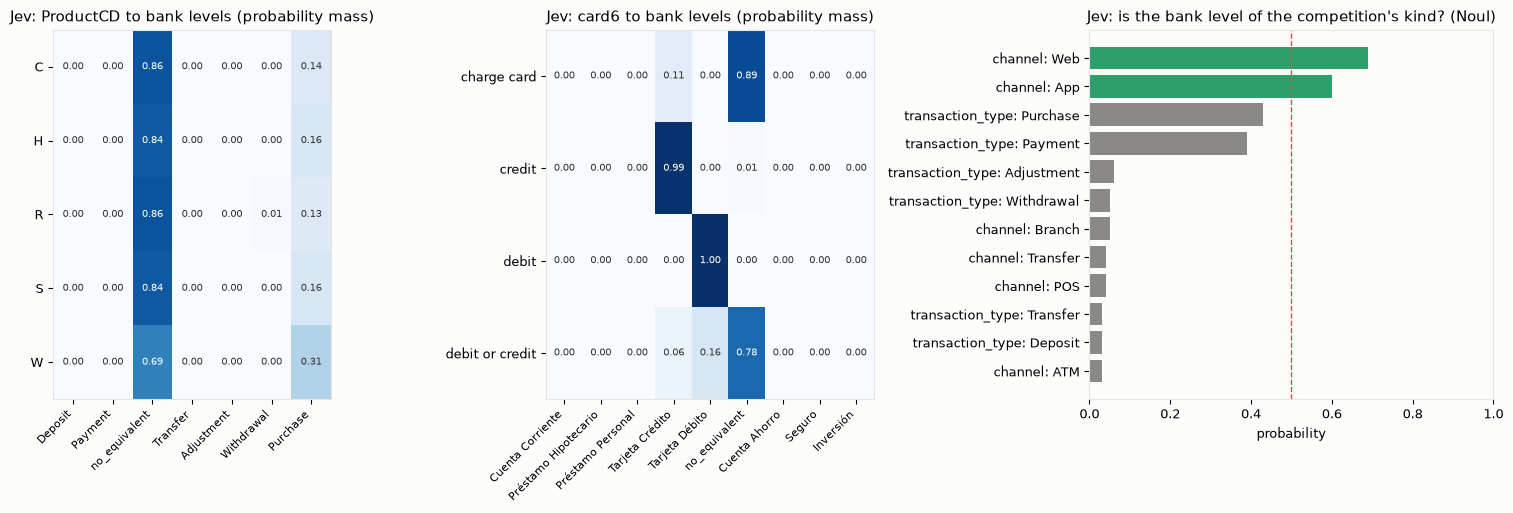

In [14]:
if len(jev_tab):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.1, 1.3, 1.6]})
    for ax, var in zip(axes[:2], ["ProductCD", "card6"]):
        sub = {k.split("||")[1]: v["probabilities"] for k, v in cache["choices"].items() if k.split("||")[0] == var}
        mat = pd.DataFrame(sub).T.fillna(0)
        im = ax.imshow(mat.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=8); ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]): ax.text(j, i, f"{mat.values[i, j]:.2f}", ha="center", va="center", fontsize=7, color="white" if mat.values[i, j] > 0.5 else "#333")
        ax.set_title(f"Jev: {var} to bank levels (probability mass)")
    ax = axes[2]
    if len(cov_tab):
        c2 = cov_tab.sort_values("p_competition_kind")
        ax.barh(c2.bank_var + ": " + c2.level, c2.p_competition_kind, color=[GREEN if p >= 0.5 else GRAY for p in c2.p_competition_kind])
        ax.axvline(0.5, color=RED, ls="--", lw=1); ax.set_xlim(0, 1); ax.set_title("Jev: is the bank level of the competition's kind? (Noul)"); ax.set_xlabel("probability")
    plt.tight_layout(); plt.savefig("notebooks/21_jev_level_homologation.png", dpi=130, bbox_inches="tight"); plt.show()

Reading the Jev tables: a level with confidence at or above 0.70 is homologated as Jev says; a split distribution (for example `ProductCD`, whose codes Vesta never explained) is left to a human, with Jev's second choice shown; `no_equivalent` with mass above 0.5 means the level stays out of the contract (the card network is the clear case). The coverage answers define where the transferred score is served and where the rules baseline stays: online channels are the competition's kind, ATM, POS and branch movements are not.

## What this means

- **The contract is computable on both sides with one definition each**, including the winning recipe's client-id aggregations, which on our side are native (`product_id`) instead of reconstructed.
- **Signal exists only on the competition side.** Every contract feature scores 0.50 against the bank's `is_fraud`, as in notebooks 02 to 04, and well above it against the competition's `isFraud`. The learned score has to come from the transfer; nothing in the bank data can train it.
- **The domain gap is real and cannot be transformed away.** The sources stay separable under every encoding tested (raw, raw without the fingerprint, per-source ranks); the discrete features (address bucket, card kind, cents, consistency) differ in proportion and the continuous ones in joint structure. Consequences: the transferred model's absolute probabilities mean nothing on the bank side (hence the percentile threshold), the ablation tests the discrete block as a whole, and the report states the gap with these numbers instead of claiming the two worlds are alike. Those go into the model as ranks or bins, computed per source, and the served threshold is a percentile of our own window, as the spec says. Features with signal and overlap go in as they are.
- **Features to drop or to leave to the ablation** are listed above; `card_not_present` is constant in the competition and cannot be learned, so the rules baseline keeps covering the card-present channels.
- The categorical levels are homologated in section 5 with Jev's typed answers, cached in `notebooks/05_jev_level_homologation.json`; the ambiguous ones go to the mentors with TQ-026.
- Next: implement the contract builder and the competition adapter from this notebook's definitions (spec section 8), train on the competition's time split, and report the ablation with and without the shifted features.